# The Itô Integral: From “Process → Random Variable” to “Process → Process”

This notebook is a **visual reading** companion for the Itô integral:

* **Definite Itô integral**: integrand process $f$ ↦ random variable $\int_0^T f\,dB$ (a single number).
* **Indefinite / process version**: integrand process $f$ ↦ process $X_t=\int_0^t f\,dB$ (a whole path).

Why this matters: almost everything in stochastic calculus (Itô’s formula, SDEs, hedging, martingale representation) needs the **process** $(X_t)_{t\le T}$, not just the terminal value $X_T$.

---

## Roadmap

1. Integrands: adapted vs progressive; simple processes
2. Definite Itô integral: simple ↦ $L^2(\Omega)$ random variable; Itô isometry
3. Extension by completion: $H^2$ / $L^2$-type spaces (Hilbert-space view)
4. The “naïve” process definition and the uncountable null-set problem
5. The correct process construction: approximations + Doob control
6. Visual experiments:
   - approximating $\int_0^t B_s\,dB_s$ and seeing uniform convergence
   - checking Itô isometry numerically
   - a toy demonstration of the “version problem”
7. Beyond $H^2$: localization ($L^2_{\text{loc}}$)


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

rng = np.random.default_rng(4)

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

_fig_counter = 0
def show_caption(text, label=None):
    global _fig_counter
    _fig_counter += 1
    prefix = f"**Figure {_fig_counter}.** "
    if label is not None:
        prefix += f"({label}) "
    display(Markdown(prefix + text))


## 1. Integrands: what “non-anticipating” really means

To define \(\int_0^T f\,dB\), the integrand must not “look into the future.”

A clean entry point (Klebaner) is: on each interval \((t_i,t_{i+1}]\), the coefficient \(\xi_i\) is allowed to depend on \(\{B(s): s\le t_i\}\), but not on values after \(t_i\). This is exactly the condition \(\xi_i\) being \(\mathcal F_{t_i}\)-measurable.  
Klebaner also emphasizes that **adaptedness alone** is not quite enough for some theorems; one typically uses the stronger measurability notion of **progressive** (progressively measurable).

**Mental model:**  
- adapted: each snapshot \(f(t)\) is measurable w.r.t. the past up to \(t\)  
- progressive: the whole map \((t,\omega)\mapsto f(t,\omega)\) is measurable on each strip \([0,t]\times\Omega\)

In practice, “regular adapted” (càdlàg) processes are progressive, so we usually work with those.

## 1. Integrands: what “non-anticipating” really means

To define $\int_0^T f\,dB$, the integrand must not “look into the future.”

A clean entry point is: on each interval $(t_i,t_{i+1}]$, the coefficient $\xi_i$ is allowed to depend on $\{B(s): s\le t_i\}$, but not on values after $t_i$. This is exactly the condition $\xi_i$ being $\mathcal F_{t_i}$-measurable.

**adaptedness alone** is not quite enough for some theorems; one typically uses the stronger measurability notion of **progressive** (progressively measurable).

**Mental model:** 
- adapted: each snapshot $f(t)$ is measurable w.r.t. the past up to $t$
- progressive: the whole map $(t,\omega)\mapsto f(t,\omega)$ is measurable on each strip $[0,t]\times\Omega$

In practice, “regular adapted” (càdlàg) processes are progressive, so we usually work with those.


## 2. Definite Itô integral: “process → random variable”

### 2.1 Start with simple processes

For a simple adapted process $f$ of the form

$$f(t)=\sum_{i=0}^{n-1}\xi_i\,\mathbf 1_{(t_i,t_{i+1}]}(t),\qquad \xi_i\in \mathcal F_{t_i},$$

define the **definite** Itô integral (terminal value at $T$) by the sum

$$I(f):=\int_0^T f\,dB=\sum_{i=0}^{n-1} \xi_i\,(B_{t_{i+1}}-B_{t_i}).$$

This is already a random variable in $L^2(\Omega)$ if $\mathbb E[\xi_i^2]<\infty$.

### 2.2 The magic identity: Itô isometry

For Brownian motion (or more generally continuous martingales), we have

$$\mathbb E\!\left[\left(\int_0^T f\,dB\right)^2\right]=\mathbb E\!\left[\int_0^T f(t)^2\,dt\right].$$

This turns stochastic integration into **Hilbert-space geometry**: the integral map is an isometry from an $L^2$-space of integrands into $L^2(\Omega)$ random variables.


## 3. Extension by completion: the Hilbert-space viewpoint (why this is clean)

A major textbook perspective (e.g. Brownian Motion, Martingales And Stochastic Calculus) is to define a space of integrands as an $L^2$ space on $\Omega\times\mathbb R_+$ with measure $dP\,d\langle M\rangle$, identify processes that agree $d\langle M\rangle$-a.e., and then extend the integral from elementary processes by density.

Conceptually:

* **simple / elementary integrands** are dense,
* Itô isometry gives **Cauchy control**,
* completeness gives a unique limit integral.

This constructs $\int_0^T f\,dB$ as a well-defined $L^2$ random variable.


## 4. The process problem: why the “obvious” definition fails

We now want an **indefinite integral process**

$$X_t := \int_0^t f\,dB,\qquad t\in[0,T].$$

A tempting idea is to define a process by

$$\widetilde I(f)(t) := I(\mathbf 1_{[0,t]}f),$$

i.e. just integrate the truncated integrand up to time $t$.

**But:** for each fixed $t$, $I(\mathbf 1_{[0,t]}f)$ is only defined as an $L^2$-equivalence class, so you may change its value on a $P$-null set $A_t\in\mathcal F_t$. If you choose different versions for different $t$, the “process” becomes ill-defined on the union $\bigcup_{t\in[0,T]}\{t\}\times A_t$, which may have nonzero measure because it is an uncountable union of null sets.

So: *a family of random variables (one for each t) is not automatically a stochastic process with good path properties.*


### A finite toy illustration of the “version problem”

We cannot literally take an uncountable union on a computer, but we can mimic the pathology:

* Suppose at each time-grid point $t_j$ you are allowed to alter the value on an event $A_{t_j}$ of tiny probability $\approx \varepsilon/N$.
* If you do this for $N$ different times, the union can have probability about $\varepsilon$.

So “each time separately is fine” does **not** imply “the whole time-indexed family is fine.”


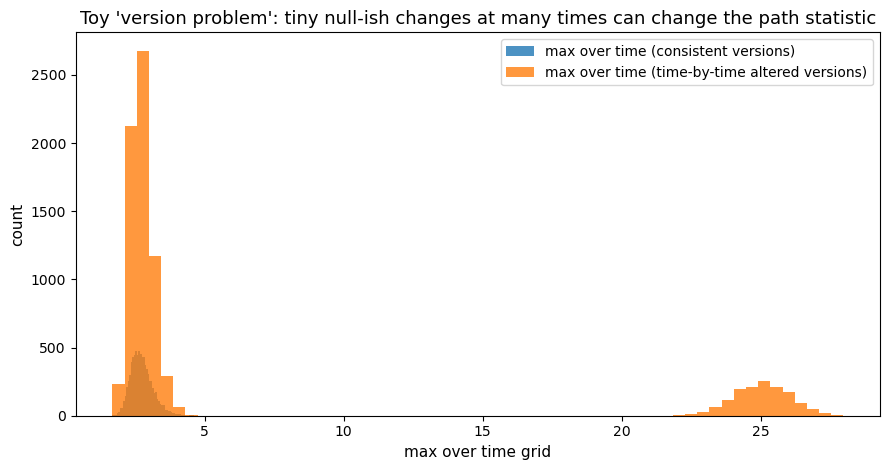

**Figure 1.** A finite analogue of the 'uncountable union of null sets' issue: changing versions on tiny events at many times can significantly alter pathwise quantities like maxima.

In [2]:
# Toy demonstration

n_paths = 8000
N_times = 200
eps = 0.20  # target union probability scale
p_each = eps / N_times

# Base process values
base = rng.standard_normal((n_paths, N_times))

# Now corrupt each time j on a tiny event A_j of probability p_each:
corrupted = base.copy()
for j in range(N_times):
    A = rng.random(n_paths) < p_each
    corrupted[A, j] += 25.0  # huge spike: "pick a bad version on A_j"

# Compare a pathwise statistic: max over time
max_base = base.max(axis=1)
max_corr = corrupted.max(axis=1)

plt.figure()
plt.hist(max_base, bins=60, alpha=0.8, label="max over time (consistent versions)")
plt.hist(max_corr, bins=60, alpha=0.8, label="max over time (time-by-time altered versions)")
plt.title("Toy 'version problem': tiny null-ish changes at many times can change the path statistic")
plt.xlabel("max over time grid")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

show_caption(
    "A finite analogue of the 'uncountable union of null sets' issue: changing versions on tiny events at many times "
    "can significantly alter pathwise quantities like maxima."
)


## 5. The correct process construction: build a continuous martingale version

A standard construction resolves the issue by **constructing a single process** $X=(X_t)_{t\le T}$ such that

$$\mathbb P\!\left(X_t = I(\mathbf 1_{[0,t]}f)\right)=1 \quad \text{for every fixed } t,$$

and such that $X_t$ has **continuous paths** and is a martingale.

The blueprint is:

1. Approximate $f\in H^2$ by simple processes $f_n$ in $L^2([0,T]\times\Omega)$.
2. For each $f_n$, define the genuine process

$$X^{(n)}_t := I(\mathbf 1_{[0,t]} f_n),$$



which is explicitly a continuous adapted martingale (because $f_n$ is piecewise constant).
3. Use **Doob’s $L^2$ inequality** + Itô isometry to control the sup norm:

$$\mathbb P\!\left(\sup_{t\le T}|X^{(n)}_t-X^{(m)}_t|>\varepsilon\right) \le \frac{1}{\varepsilon^2}\,\|X^{(n)}_T-X^{(m)}_T\|_2^2 = \frac{1}{\varepsilon^2}\,\|f_n-f_m\|_2^2.$$


4. Extract a subsequence with almost sure uniform convergence (Borel–Cantelli), yielding a continuous limit process $X$.

This is the “definite → indefinite” transition done correctly: **terminal L² control ⇒ pathwise (sup) control.**


## 6. Visual experiment: approximating $\int_0^t B_s\,dB_s$

A canonical test integrand is $f(s)=B_s$. It is adapted, square-integrable on finite horizons, and we even know the closed form:

$$\int_0^t B_s\,dB_s = \frac{B_t^2 - t}{2}.$$

We will:

* simulate one Brownian path $B_t$,
* approximate the Itô integral process using left-point step integrands on dyadic partitions,
* plot convergence of the **whole path** $X^{(n)}_t$ to the closed-form target.


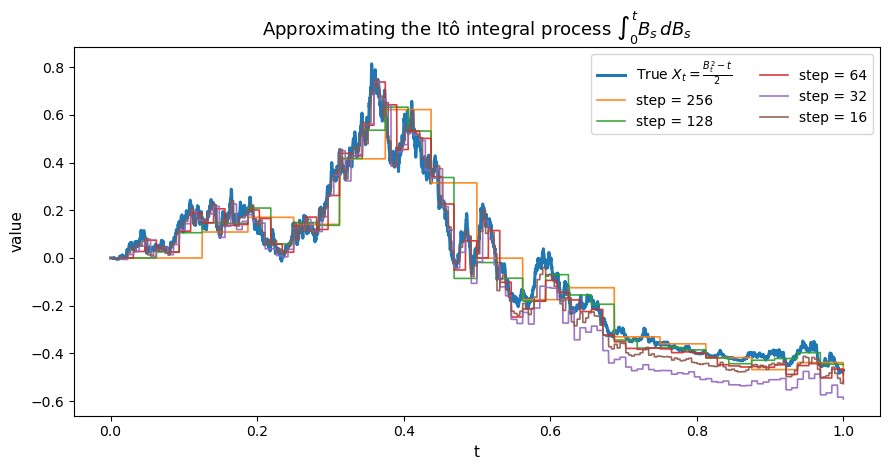

**Figure 2.** Process-level convergence: step-function approximations (left-point) converge to the Itô integral process. This is the 'process → process' viewpoint in action.

In [3]:
def simulate_brownian_path(T=1.0, N=4096, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    dt = T / N
    dB = np.sqrt(dt) * rng.standard_normal(N)
    B = np.concatenate([[0.0], np.cumsum(dB)])
    t = np.linspace(0.0, T, N+1)
    return t, B, dB, dt

def ito_integral_process_left_step(B, dB, coarse_step):
    # Build step integrand f_n(s)=B_{t_i} on blocks of size coarse_step (in fine-grid indices)
    N = len(dB)
    assert N % coarse_step == 0
    n_blocks = N // coarse_step
    
    # coarse increments
    dB_coarse = dB.reshape(n_blocks, coarse_step).sum(axis=1)
    # left endpoints at coarse times
    B_left = B[0:N:coarse_step]
    # cumulative integral process at coarse times:
    incr = B_left * dB_coarse
    X_coarse = np.concatenate([[0.0], np.cumsum(incr)])
    # lift to fine grid (piecewise constant between coarse times for visualization)
    X_fine = np.repeat(X_coarse[:-1], coarse_step)
    X_fine = np.concatenate([X_fine, [X_coarse[-1]]])  # align lengths N+1
    return X_fine, X_coarse

T = 1.0
N = 4096
t, B, dB, dt = simulate_brownian_path(T=T, N=N, rng=rng)

# Target process: (B_t^2 - t)/2
X_true = 0.5*(B**2 - t)

# Approximations at different meshes
coarse_steps = [256, 128, 64, 32, 16]  # finer -> better
X_approx = []
for cs in coarse_steps:
    Xf, _ = ito_integral_process_left_step(B, dB, cs)
    X_approx.append(Xf)

plt.figure()
plt.plot(t, X_true, linewidth=2.2, label=r"True $X_t=\frac{B_t^2-t}{2}$")
for cs, Xf in zip(coarse_steps, X_approx):
    plt.plot(t, Xf, linewidth=1.2, alpha=0.9, label=f"step = {cs}")
plt.title(r"Approximating the Itô integral process $\int_0^t B_s\,dB_s$")
plt.xlabel("t")
plt.ylabel("value")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

show_caption(
    "Process-level convergence: step-function approximations (left-point) converge to the Itô integral process. "
    "This is the 'process → process' viewpoint in action."
)


## 7. Visual experiment: “terminal control ⇒ pathwise control” (Doob + isometry)

The construction uses Doob’s inequality to bound a sup deviation by a terminal $L^2$ deviation.

We mimic this numerically by comparing two approximations $X^{(n)}$ and $X^{(m)}$ of the integral process:

* compute $\sup_{t\le T}|X^{(n)}_t-X^{(m)}_t|$ over sample paths,
* compare it to the terminal difference $|X^{(n)}_T-X^{(m)}_T|$.

The inequality is not an equality, but it tells you **the right scaling**: controlling the terminal error in $L^2$ controls the whole-path error.


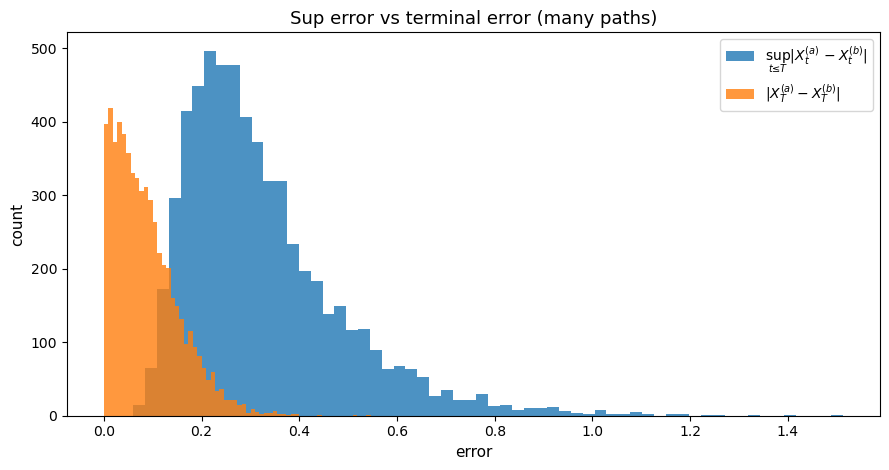

**Figure 3.** Supremum error is typically larger than terminal error, but Doob-type inequalities provide a universal way to control the pathwise deviation using terminal L² information.

In [4]:
def sup_norm_diff(X1, X2):
    return np.max(np.abs(X1 - X2), axis=1)

def terminal_diff(X1, X2):
    return np.abs(X1[:, -1] - X2[:, -1])

# Monte Carlo over many independent Brownian paths
T = 1.0
N = 2048
n_paths = 6000

coarse_a = 64
coarse_b = 16

sup_diffs = []
term_diffs = []

for _ in range(n_paths):
    t, B, dB, dt = simulate_brownian_path(T=T, N=N, rng=rng)
    Xa, _ = ito_integral_process_left_step(B, dB, coarse_a)
    Xb, _ = ito_integral_process_left_step(B, dB, coarse_b)
    sup_diffs.append(np.max(np.abs(Xa - Xb)))
    term_diffs.append(abs(Xa[-1] - Xb[-1]))

sup_diffs = np.array(sup_diffs)
term_diffs = np.array(term_diffs)

plt.figure()
# Fixed labels by using r"$" syntax properly for LaTeX rendering
plt.hist(sup_diffs, bins=60, alpha=0.8, label=r"$\sup_{t \leq T}|X^{(a)}_t-X^{(b)}_t|$")
plt.hist(term_diffs, bins=60, alpha=0.8, label=r"$|X^{(a)}_T-X^{(b)}_T|$")
plt.title("Sup error vs terminal error (many paths)")
plt.xlabel("error")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

show_caption(
    "Supremum error is typically larger than terminal error, but Doob-type inequalities provide a universal way "
    "to control the pathwise deviation using terminal L² information."
)

## 8. Visual experiment: Itô isometry check (definite integral)

For the integrand $f(s)=B_s$, Itô’s formula implies

$$\int_0^T B_s\,dB_s = \frac{B_T^2 - T}{2}.$$

So we can compare Monte Carlo estimates of

$$\mathbb E\!\left[\left(\int_0^T B_s\,dB_s\right)^2\right] \quad \text{and}\quad \mathbb E\!\left[\int_0^T B_s^2\,ds\right].$$

They should match (Itô isometry).


In [5]:
# Monte Carlo for Ito isometry with f=B
T = 1.0
N = 4096
n_paths = 20000

lhs = []
rhs = []

for _ in range(n_paths):
    t, B, dB, dt = simulate_brownian_path(T=T, N=N, rng=rng)
    # exact integral from Ito formula:
    I = 0.5*(B[-1]**2 - T)
    lhs.append(I**2)
    rhs.append(np.sum(B[:-1]**2)*dt)  # Riemann approx to ∫ B_s^2 ds

lhs = np.mean(lhs)
rhs = np.mean(rhs)

print("Ito isometry check (Monte Carlo)")
print("E[(∫ B dB)^2] ≈", lhs)
print("E[∫ B^2 ds]   ≈", rhs)


Ito isometry check (Monte Carlo)
E[(∫ B dB)^2] ≈ 0.4858419205421452
E[∫ B^2 ds]   ≈ 0.5014059599148711


## 9. Beyond $H^2$: localization ($L^2_{\text{loc}}$)

Sometimes $f$ is not in $H^2$ globally, but is square-integrable **up to stopping times**.
A standard localization argument uses an increasing sequence of stopping times $(\nu_n)$ such that the truncated process

$$\tilde f_n(t,\omega)=f(t,\omega)\,\mathbf 1_{\{t\le \nu_n(\omega)\}}$$

belongs to $H^2$ for each $n$, and $\mathbb P(\cup_n\{\nu_n=T\})=1$.
Then $\int_0^t f\,dB$ is defined consistently by patching together the stopped integrals.

This is how stochastic integrals extend to $L^2_{\text{loc}}$ integrands and eventually to semimartingales.
